# Week 01 Assignment Starter Notebook: From Words to Sequences  
## NLP Foundations and a First RNN

**Course:** TECH 77 — Modern AI Architectures: From RNNs to Chatbots  
**Format:** Google Colab  
**Estimated Time:** 1.5–2 hours  

### Assignment Overview

In this assignment, you will work through a simple NLP pipeline and train a basic RNN for sentiment classification.

This assignment has two parts:

1. **NLP Foundations:** Inspect text, decode reviews, tokenize text, and examine word frequencies.
2. **First RNN Model:** Convert reviews into padded sequences and train a simple RNN classifier.

## Learning Objectives

By the end of this assignment, you should be able to:

- Explain why text must be converted into numbers for machine learning
- Tokenize and inspect text data
- Identify common words in a text dataset
- Pad sequences to a fixed length
- Build and train a simple RNN model
- Interpret basic model accuracy and loss

## Part 0: Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import string
from collections import Counter

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import string
from collections import Counter

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

np.random.seed(42)
tf.random.set_seed(42)

## Part 1: Load the IMDb Dataset

We will use the IMDb movie review dataset. Each review is labeled as:

- `0` = negative review
- `1` = positive review

To keep the assignment manageable, we will only use the top 5,000 most frequent words.

In [8]:
vocab_size = 5000
max_len = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Training samples:", (x_train[1]))
print("Testing samples:", len(x_test))
print("Testing samples:", (x_test[1]))
print("First review as numbers:", x_train[0][:20])
print("First label:", y_train[0])

Training samples: 25000
Training samples: [1, 194, 1153, 194, 2, 78, 228, 5, 6, 1463, 4369, 2, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 2, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 2, 5, 163, 11, 3215, 2, 4, 1153, 9, 194, 775, 7, 2, 2, 349, 2637, 148, 605, 2, 2, 15, 123, 125, 68, 2, 2, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 2, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 2, 5, 2, 656, 245, 2350, 5, 4, 2, 131, 152, 491, 18, 2, 32, 2, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]
Testing samples: 25000
Testing samples: [1, 14, 22, 3443, 6, 176, 7, 2, 88, 12, 2679, 23, 1310, 5, 109, 943, 4, 114, 9, 55, 606, 5, 111, 7, 4, 139, 193, 273

## Part 2: Decode Reviews

The dataset stores reviews as numbers. The next cell creates a helper function to convert the numbers back into words.

In [5]:
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_review])

In [10]:
# TODO 1:
# Print the first decoded review and its label.
# Hint: use decode_review(x_train[0])

#print(decode_review(x_train[0]),(y_train[0]))
print(decode_review(x_train[0]),(y_train[0]))
# YOUR CODE HERE

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly <UNK> was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little <UNK> that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big <UNK> for the whole film but these children are amazing and should be <UNK> for what they

### Question 1

In 2–3 sentences, describe what you notice about the decoded review.  
Does the text look clean? Do you notice any special tokens such as `<START>` or `<UNK>`?

**Your answer:** The text doesnt look clean it has special characters like <START> which I think are part of the reverse_word_index[1] and reverse_word_index[2] Though regardless of the special characters the review makes sense as it is about the scottish film.

## Part 3: Simple Tokenization

In this section, you will write a small function to clean and tokenize text.

The function should:
- Convert text to lowercase
- Remove punctuation
- Split the text into words
- Remove special tokens

In [18]:
def simple_tokenize(text):
    # TODO 2:
    # 1. Convert text to lowercase
    # 2. Remove punctuation
    # 3. Split the text into words
    # 4. Remove the special tokens: start, unk, pad, unused

    # YOUR CODE HERE
    word = text
    word_lower_case = word.lower() # converts text to lowercase
    clear_punctuation = ''.join(char for char in word_lower_case if char not in string.punctuation) # removes punctution
    split_text_words = clear_punctuation.split()
    special_tokens = { "start" ,"unk" , "pad" , "unused"}
    clean_spcl_tokens = [word for word in split_text_words if word not in special_tokens]
    #clean_review = " ".join(clean_spcl_tokens)
    #tokens = clean_review
    tokens = clean_spcl_tokens
    return tokens

sample_text = decode_review(x_train[0])
tokens = simple_tokenize(sample_text)
print(tokens[:40])

['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', 'is', 'an', 'amazing', 'actor', 'and', 'now', 'the', 'same', 'being', 'director', 'father', 'came', 'from', 'the', 'same']


## Part 4: Find Common Words

We will analyze the first 500 reviews to keep this quick.

In [21]:
num_reviews = 500
all_tokens = []

# TODO 3:
# Loop through the first 500 training reviews.
# Decode each review, tokenize it, and add the tokens to all_tokens.

# YOUR CODE HERE

for i in range(num_reviews):
    decoded = decode_review(x_train[i])
    tokens = simple_tokenize(decoded)
    all_tokens.extend(tokens)
print(all_tokens[:40])
    
word_counts = Counter(all_tokens)
top_15_words = word_counts.most_common(15)


['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', 'is', 'an', 'amazing', 'actor', 'and', 'now', 'the', 'same', 'being', 'director', 'father', 'came', 'from', 'the', 'same']


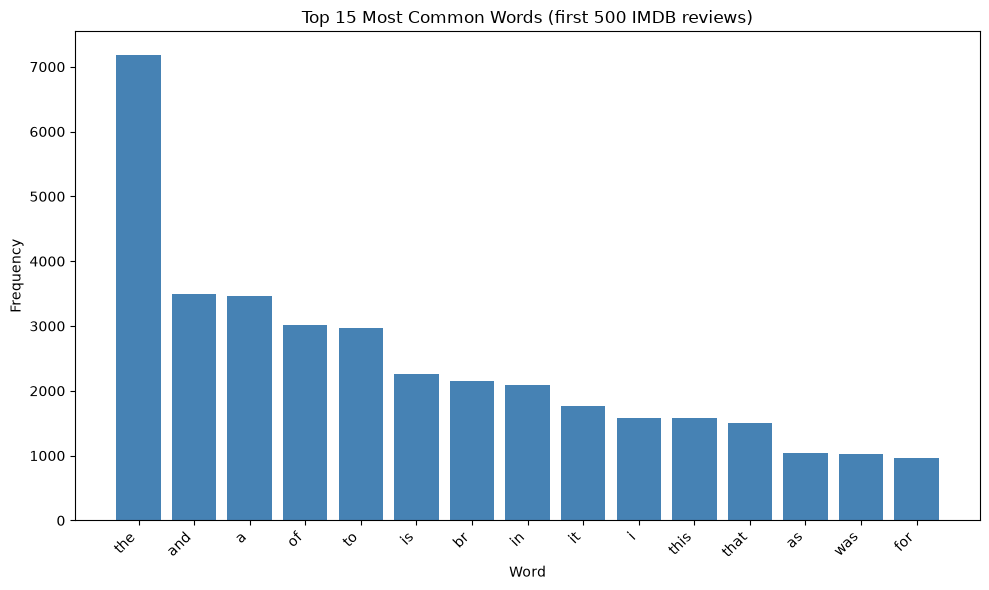

In [23]:
# TODO 4:
# Create a bar plot of the top 15 words.
# Hint: separate top_15_words into two lists: words and counts.

# YOUR CODE HERE'
words, counts = zip(*top_15_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='steelblue')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 15 Most Common Words (first 500 IMDB reviews)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Question 2

Are the most frequent words always the most meaningful words for sentiment analysis? Explain briefly.

**Your answer:** No. Most frequent words are connector words like 'the,and,a,of,to'.

## Part 5: Pad the Sequences

Reviews have different lengths, but neural networks work best when inputs have the same shape.  
We will pad or truncate each review to 100 tokens.

In [25]:
# TODO 5:
# Pad the training and testing sequences using max_len.
# Use padding="post" and truncating="post".

# YOUR CODE HERE
x_train_padded = pad_sequences(x_train, maxlen=max_len, padding="post", truncating="post")
x_test_padded = pad_sequences(x_test, maxlen=max_len, padding="post", truncating="post")

print("Training shape:", x_train_padded.shape)
print("Testing shape:", x_test_padded.shape)

Training shape: (25000, 100)
Testing shape: (25000, 100)


### Question 3

Why do we need padding in this assignment?

**Your answer:** Padding is needed to standardize the input data such that the neural network can process different lengths of text with the same matrix . It saves time to have a same size than different sizes of input data. It also helps in parallelizing the training process.

## Part 6: Build a Simple RNN

The model will use:

1. An **Embedding** layer to convert word IDs into dense vectors  
2. A **SimpleRNN** layer to process the sequence  
3. A **Dense** output layer for binary classification

In [27]:
embedding_dim = 32
rnn_units = 32

model = Sequential([
    # TODO 6:
    # Add an Embedding layer.
    # input_dim should be vocab_size
    # output_dim should be embedding_dim
    # input_length should be max_len
    

    # TODO 7:
    # Add a SimpleRNN layer with rnn_units

    # TODO 8:
    # Add a Dense output layer with sigmoid activation
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(rnn_units),
    Dense(1, activation='sigmoid')
])

# TODO 9:
# Compile the model using:
# optimizer="adam"
# loss="binary_crossentropy"
# metrics=["accuracy"]

# YOUR CODE HERE
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Part 7: Train the Model

We will train for only 2 epochs to keep the assignment short.

In [39]:
history = model.fit(
    x_train_padded,
    y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8318 - loss: 0.3912 - val_accuracy: 0.7696 - val_loss: 0.4995
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8854 - loss: 0.2916 - val_accuracy: 0.7936 - val_loss: 0.4711


## Part 8: Evaluate the Model

In [30]:
# TODO 10:
# Evaluate the model on the test set and print the test accuracy.

# YOUR CODE HERE
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)
print("Test accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7200 - loss: 0.5628
Test accuracy: 0.7200400233268738


## Part 9: Plot Training Results

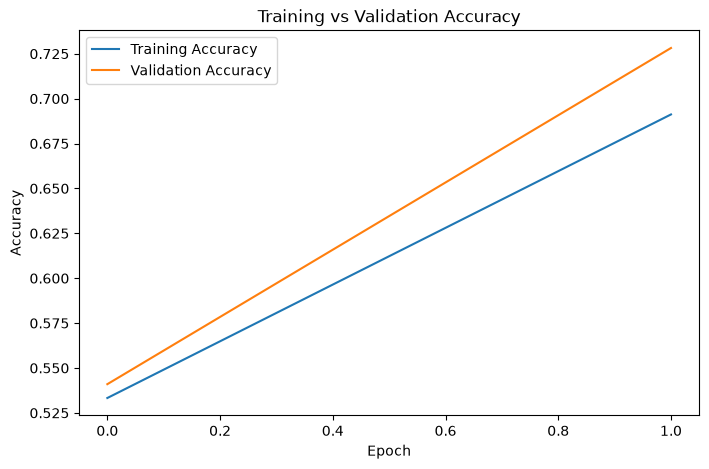

In [32]:
# TODO 11:
# Plot training accuracy and validation accuracy.

# YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### Question 4

Did the model learn something useful? Use the training, validation, and test accuracy to support your answer.

**Your answer:** Model has learnt about 2epochs of data which is very limited but useful. The training helped it to enable the model for review analysis . There is clear gap better the validation and accuracy of it as the data is very limited.

## Part 10: Try Your Own Sentences

The helper functions below convert a new sentence into the same format used by the IMDb dataset.

In [33]:
def encode_sentence(sentence):
    sentence = sentence.lower()
    sentence = sentence.translate(str.maketrans("", "", string.punctuation))
    words = sentence.split()

    encoded = [1]  # START token
    for word in words:
        index = word_index.get(word, 2) + 3
        if index < vocab_size:
            encoded.append(index)
        else:
            encoded.append(2)  # UNK token

    return pad_sequences([encoded], maxlen=max_len, padding="post", truncating="post")

def predict_sentiment(sentence):
    encoded_sentence = encode_sentence(sentence)
    prediction = model.predict(encoded_sentence, verbose=0)[0][0]
    label = "Positive" if prediction >= 0.5 else "Negative"
    return prediction, label

In [38]:
# TODO 12:
# Add three of your own movie review sentences.
# Include one positive, one negative, and one mixed/ambiguous sentence.

my_sentences = [
    "This is a very good movie where there was a clear screenplay with a good story",
    "very bad movie",
    "The movie 300 was a very good story teller but since its has a lot of adult graphics it wasn't consumable by kids"
]

for sentence in my_sentences:
    if sentence.strip():
        score, label = predict_sentiment(sentence)
        print("Sentence:", sentence)
        print("Score:", round(float(score), 4))
        print("Prediction:", label)
        print()

Sentence: This is a very good movie where there was a clear screenplay with a good story
Score: 0.6175
Prediction: Positive

Sentence: very bad movie
Score: 0.6646
Prediction: Positive

Sentence: The movie 300 was a very good story teller but since its has a lot of adult graphics it wasn't consumable by kids
Score: 0.6913
Prediction: Positive



### Question 5

How did the model perform on your custom sentences? Did any prediction surprise you?

**Your answer:** The model predicted the positive and mixed reviews almost close to accuracy but failed on identifying the negative and bad reviews.

## Final Reflection

Answer each question in 2–4 sentences.

1. Why does text need to be converted into numbers before a neural network can process it?
2. **Answer** : Any model is a mathmatical operations between layers and processing through the layers . Therefore inorder for the model to understand we would need to convert the words into numerical representation for the model to understand.
3. What is the purpose of the embedding layer?
4. **Answer** : The embedding layer helps find the relationship between catergory of words in a sentence . The relationship between them can help predit the next one . Example : King - men = Queen. 
5. Why is word order important for NLP?
6. **Answer** : Word ordering is important to understand the meaning of the sentence. Example : "Dog Eats food" => Conveys a different meaning than "Food eats Dog" => Which doesnt make any sense. 
7. What is one limitation of a simple RNN?
8. **Answer** : The RNN neural network has a problem called vanishing gradient which results in forgetting longer sentences or data along with sequential nature which hinders the parallel computation.
9. How might LSTMs, GRUs, or Transformers improve on this model?
10. **Answer** : The LSTMs and GRUs help remember the long memory by storing the relevant information and dropping of the unwanted information through gates by intelligently selecting which information is saved and which information needs to be passed on and which information needs to be dropped. Where as Transformers would help to process the sentences parallelly by attention mechanism unlike RNN where they would execute them serially. 

## Submission Checklist

Before submitting, make sure your notebook includes:

- Completed TODO sections
- Top-word frequency plot
- Padded sequence shapes
- Trained RNN model
- Test accuracy
- Accuracy plot
- Predictions for three custom sentences
- Answers to all reflection questions